In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
data = pd.read_csv('50_Startups.csv')

In [3]:
data.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [4]:
data.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [5]:
# Visual EDA to check correlation
# Correlation is always checked between a feature columns (x axis) and label column (y axis)
# Goal is to check linear relationship

<Axes: xlabel='R&D Spend', ylabel='Profit'>

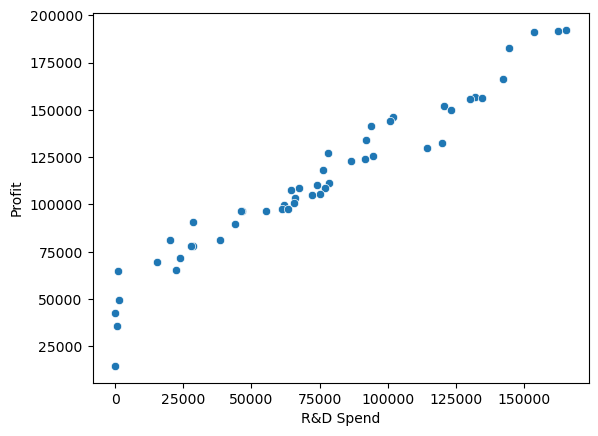

In [6]:
# Check if rdSpend and profit has linear relationship

sns.scatterplot(data=data, x="R&D Spend", y="Profit")

<Axes: xlabel='Administration', ylabel='Profit'>

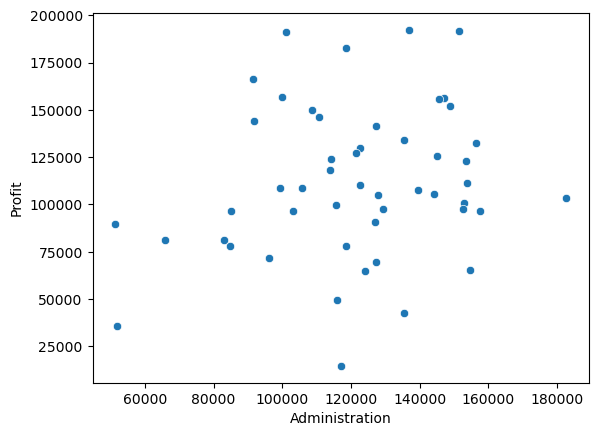

In [7]:
# Check if adminSpend and profit has linear relationship

sns.scatterplot(data=data, x="Administration", y="Profit")

<Axes: xlabel='Marketing Spend', ylabel='Profit'>

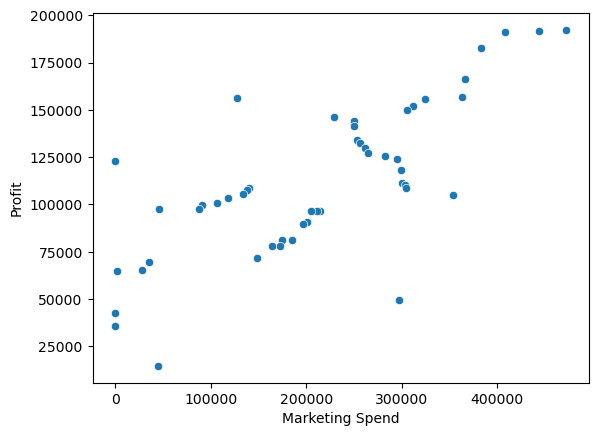

In [8]:
# Check if marketing Spend and profit has linear relationship

sns.scatterplot(data=data, x="Marketing Spend", y="Profit")

In [9]:
# Numerical EDA -  to check correlation
#
# Note: How to infer the result of corr() ------ df.corr() ---- Internally uses Pearson's Correlation formula :)
# Range of corr() ------------------- -1 to +1
#
# Interpretation:
# ========================
# if value is positive and near to +1 -----------> positive corr (strong or weak)
# if value is negative and near to -1 -----------> negative corr (strong or weak)
# if value is pos or neg but near to 0 ----------> no correlation
#
#
# Guideline by PN for threshold :)
# ===================================
#
# 1. if value is between 0.45 and 1 ----------> +ve corr
# 2. if value is between -0.45 to + 0.45 -----> no corr
# 3. if value is between -1 and -0.45 --------> -ve corr
#
# Always consult the domain expert else follow PN's another guideline to define strong or weak
#
# if value is near 1 (+0.75 and +1) ------> Strong +ve corr
# if value is near -1 (-1 and -0.75) -----> Strong -ve corr
#

In [10]:
data['R&D Spend'].corr(data['Profit'])

np.float64(0.9729004656594831)

In [11]:
data['Marketing Spend'].corr(data['Profit'])

np.float64(0.7477657217414766)

In [12]:
data['Administration'].corr(data['Profit'])

np.float64(0.2007165682687214)

## Correlation Test using Hypothesis Testing Method

In [30]:
# Performing Hypothesis Testing
#
# 1. Create a Viable Question Goal (The question must result in a Binary Outcome)
# 2. Convert the question goal into Hypothesis (h0 and h1)
# 3. Select the Statistical Testing Formula to Validate the Hypothesis (Check who wins?)
# 4. Select/Determine SL of the Project
# 5. Calc the p-value using Statistical Testing formula and compare the same with the SL to check who wins
#
#

In [14]:
# Perform Hypothesis Testing for Correlation for RDSpend and Profit
#
# ==================================================================================
#
# 1. Create a Viable Question Goal:
#
# Check if there exists any kind of linear relationship between RdSpend and Profit
#
# ===================================================================================
#
# 2. Convert the question into Hypothesis
#
#
# Null Hypothesis (H0) ---> rdSpend and Profit has NO linear relationship :(
# Alt Hypothesis (H1) ----> rdSpend and Profit has Linear Relationship :)
#
# ====================================================================================
#
# 3. Select the statistical testing formula
#
# Pearson's Correlation test Formula
#
# ====================================================================================
#
# 4. Select/Assume SL of the project
#
# SL = 0.05
#
# ====================================================================================
#
# 5. Calc the pvalue

SL = 0.05

from scipy.stats import pearsonr

#Calc pvalue
corr, pvalue = pearsonr(data['R&D Spend'], data['Profit'])

#Compare pvalue with SL

if pvalue <= SL:
  print("Alt Hypothesis (H1) ----> rdSpend and Profit has Linear Relationship :)")
  print("Correlation Value: ",corr)
  if corr >= 0.45 and corr <= 1:
    print("Strong +ve Correlation")

else:
  print("Null Hypothesis (H0) ---> rdSpend and Profit has NO linear relationship :(")


Alt Hypothesis (H1) ----> rdSpend and Profit has Linear Relationship :)
Correlation Value:  0.972900465659483
Strong +ve Correlation


In [15]:
# Perform Hypothesis Testing for Correlation for RDSpend and Profit
#
# ==================================================================================
#
# 1. Create a Viable Question Goal:
#
# Check if there exists any kind of linear relationship between markSpend and Profit
#
# ===================================================================================
#
# 2. Convert the question into Hypothesis
#
#
# Null Hypothesis (H0) ---> markSpend and Profit has NO linear relationship :(
# Alt Hypothesis (H1) ----> markSpend and Profit has Linear Relationship :)
#
# ====================================================================================
#
# 3. Select the statistical testing formula
#
# Pearson's Correlation test Formula
#
# ====================================================================================
#
# 4. Select/Assume SL of the project
#
# SL = 0.05
#
# ====================================================================================
#
# 5. Calc the pvalue

SL = 0.05

from scipy.stats import pearsonr

#Calc pvalue
corr, pvalue = pearsonr(data['Marketing Spend'], data['Profit'])

#Compare pvalue with SL

if pvalue <= SL:
  print("Alt Hypothesis (H1) ----> markSpend and Profit has Linear Relationship :)")

else:
  print("Null Hypothesis (H0) ---> markSpend and Profit has NO linear relationship :(")


Alt Hypothesis (H1) ----> markSpend and Profit has Linear Relationship :)


In [16]:
# Check if admin cost has any impact on company profit

# Perform Hypothesis Testing for Correlation for RDSpend and Profit
#
# ==================================================================================
#
# 1. Create a Viable Question Goal:
#
# Check if there exists any kind of linear relationship between adminSpend and Profit
#
# ===================================================================================
#
# 2. Convert the question into Hypothesis
#
#
# Null Hypothesis (H0) ---> adminSpend and Profit has NO linear relationship :(
# Alt Hypothesis (H1) ----> adminSpend and Profit has Linear Relationship :)
#
# ====================================================================================
#
# 3. Select the statistical testing formula
#
# Pearson's Correlation test Formula
#
# ====================================================================================
#
# 4. Select/Assume SL of the project
#
# SL = 0.05
#
# ====================================================================================
#
# 5. Calc the pvalue

SL = 0.05

from scipy.stats import pearsonr

#Calc pvalue
corr, pvalue = pearsonr(data['Administration'], data['Profit'])

#Compare pvalue with SL

if pvalue <= SL:
  print("Alt Hypothesis (H1) ----> adminSpend and Profit has Linear Relationship :)")

else:
  print("Null Hypothesis (H0) ---> adminSpend and Profit has NO linear relationship :(")


Null Hypothesis (H0) ---> adminSpend and Profit has NO linear relationship :(


## Normality Test

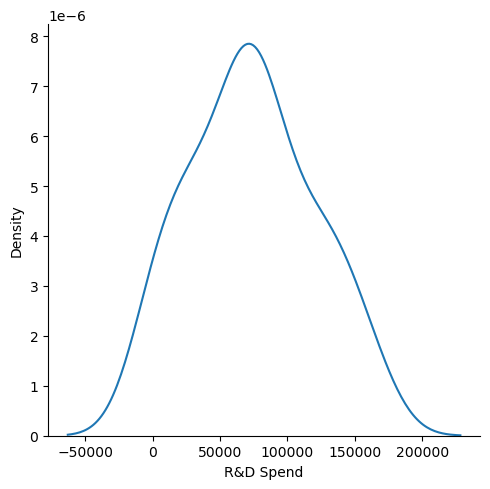

In [17]:
# Normality Test ---> Goal is to check if the given column/variable follow Normal Distribution
#Visual EDA

#rdSpend

sns.displot(data['R&D Spend'], kind="kde")

In [29]:
# Numerical EDA for Normality Test
#
# Skewness and Kurtosis
#
# The above two metrics can help identify how much deviation from normality
#
# a. Skewness: Measuring the asymmetry in normal distribution (if the value is close to 0, its normal distribution)
# b. Kurtosis: Measuring the peakedness (Should is close to 3 for normal distribution)
#
#

In [19]:
print("Skewness is ", data['R&D Spend'].skew())
print("Kurtosis is ", data['R&D Spend'].kurt())

Skewness is  0.164002172321177
Kurtosis is  -0.7614645568424674


In [20]:
# Perform Hypothesis Testing for Normality Test of RDSpend variable
#
# ==================================================================================
#
# 1. Create a Viable Question Goal:
#
# Check if rdSpend is Normally Distributed
#
# ===================================================================================
#
# 2. Convert the question into Hypothesis
#
#
# Null Hypothesis (H0) ---> rdSpend is NOT normally distributed :(
# Alt Hypothesis (H1) ----> rdSpend is NORMALLY Distributed :)
#
# ====================================================================================
#
# 3. Select the statistical testing formula
#
# Shaprio test Formula
#
# ====================================================================================
#
# 4. Select/Assume SL of the project
#
# SL = 0.05
#
# ====================================================================================
#
# 5. Calc the pvalue

SL = 0.05

from scipy.stats import shapiro

#Calc pvalue
wStatistic, pvalue = shapiro(data['R&D Spend'])

#Compare pvalue with SL

if pvalue >= SL:
  print("Alt Hypothesis (H1) ----> rdSpend is NORMALLY Distributed :)")

else:
  print("Null Hypothesis (H0) ---> rdSpend is NOT normally distributed :(")


Alt Hypothesis (H1) ----> rdSpend is NORMALLY Distributed :)


In [21]:
#Test Normality for
# adminSpend
# markSpend
# profit

In [22]:
# Perform Hypothesis Testing for Normality Test of AdminSpend variable
#
# ==================================================================================
#
# 1. Create a Viable Question Goal:
#
# Check if adminSpend is Normally Distributed
#
# ===================================================================================
#
# 2. Convert the question into Hypothesis
#
#
# Null Hypothesis (H0) ---> adminSpend is NOT normally distributed :(
# Alt Hypothesis (H1) ----> adminSpend is NORMALLY Distributed :)
#
# ====================================================================================
#
# 3. Select the statistical testing formula
#
# Shaprio test Formula
#
# ====================================================================================
#
# 4. Select/Assume SL of the project
#
# SL = 0.05
#
# ====================================================================================
#
# 5. Calc the pvalue

SL = 0.05

from scipy.stats import shapiro

#Calc pvalue
wStatistic, pvalue = shapiro(data['Administration'])

#Compare pvalue with SL

if pvalue >= SL:
  print("Alt Hypothesis (H1) ----> adminSpend is NORMALLY Distributed :)")

else:
  print("Null Hypothesis (H0) ---> adminSpend is NOT normally distributed :(")


Alt Hypothesis (H1) ----> adminSpend is NORMALLY Distributed :)


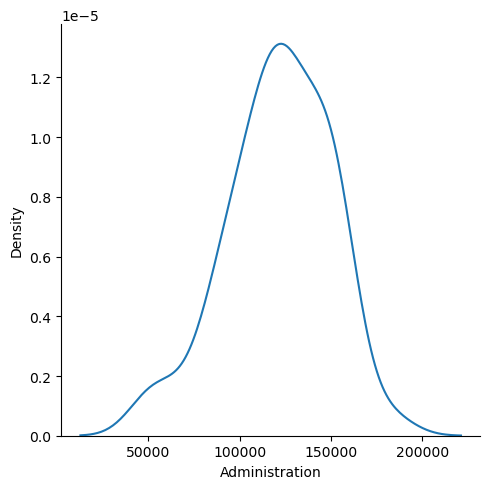

In [28]:
sns.displot(data['Administration'], kind="kde")

In [24]:
# Perform Hypothesis Testing for Normality Test of markSpend variable
#
# ==================================================================================
#
# 1. Create a Viable Question Goal:
#
# Check if markSpend is Normally Distributed
#
# ===================================================================================
#
# 2. Convert the question into Hypothesis
#
#
# Null Hypothesis (H0) ---> markSpend is NOT normally distributed :(
# Alt Hypothesis (H1) ----> markSpend is NORMALLY Distributed :)
#
# ====================================================================================
#
# 3. Select the statistical testing formula
#
# Shaprio test Formula
#
# ====================================================================================
#
# 4. Select/Assume SL of the project
#
# SL = 0.05
#
# ====================================================================================
#
# 5. Calc the pvalue

SL = 0.05

from scipy.stats import shapiro

#Calc pvalue
wStatistic, pvalue = shapiro(data['Marketing Spend'])

#Compare pvalue with SL

if pvalue >= SL:
  print("Alt Hypothesis (H1) ----> markSpend is NORMALLY Distributed :)")

else:
  print("Null Hypothesis (H0) ---> markSpend is NOT normally distributed :(")


Alt Hypothesis (H1) ----> markSpend is NORMALLY Distributed :)


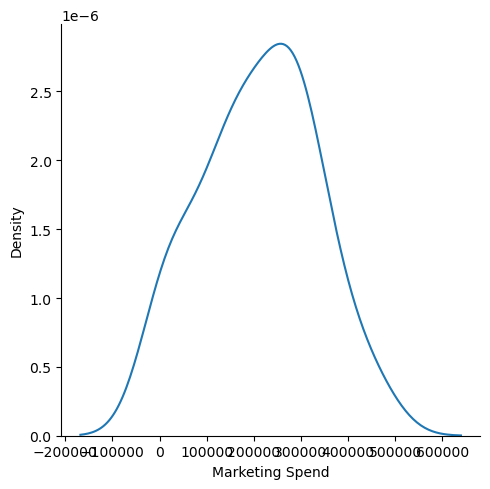

In [25]:
sns.displot(data["Marketing Spend"], kind="kde")

In [26]:
# Perform Hypothesis Testing for Normality Test of profit variable
#
# ==================================================================================
#
# 1. Create a Viable Question Goal:
#
# Check if profit is Normally Distributed
#
# ===================================================================================
#
# 2. Convert the question into Hypothesis
#
#
# Null Hypothesis (H0) ---> profit is NOT normally distributed :(
# Alt Hypothesis (H1) ----> profit is NORMALLY Distributed :)
#
# ====================================================================================
#
# 3. Select the statistical testing formula
#
# Shaprio test Formula
#
# ====================================================================================
#
# 4. Select/Assume SL of the project
#
# SL = 0.05
#
# ====================================================================================
#
# 5. Calc the pvalue

SL = 0.05

from scipy.stats import shapiro

#Calc pvalue
wStatistic, pvalue = shapiro(data['Profit'])

#Compare pvalue with SL

if pvalue >= SL:
  print("Alt Hypothesis (H1) ----> profit is NORMALLY Distributed :)")

else:
  print("Null Hypothesis (H0) ---> profit is NOT normally distributed :(")


Alt Hypothesis (H1) ----> profit is NORMALLY Distributed :)


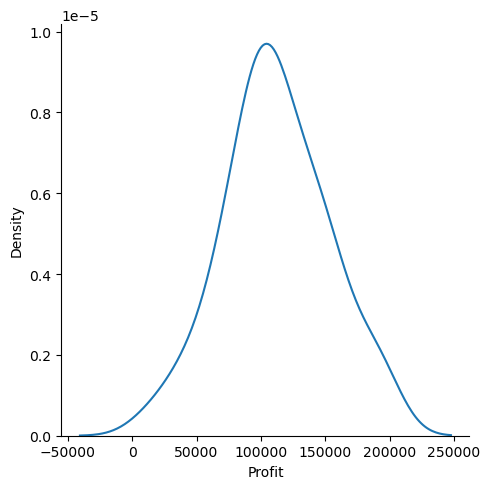

In [27]:
sns.displot(data['Profit'], kind="kde")